In [79]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [80]:
# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 150
Number of features: 4


In [81]:
# Convert dataset into a DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [82]:
# Display basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nSpecies Count:")
print(df["species"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Species Count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


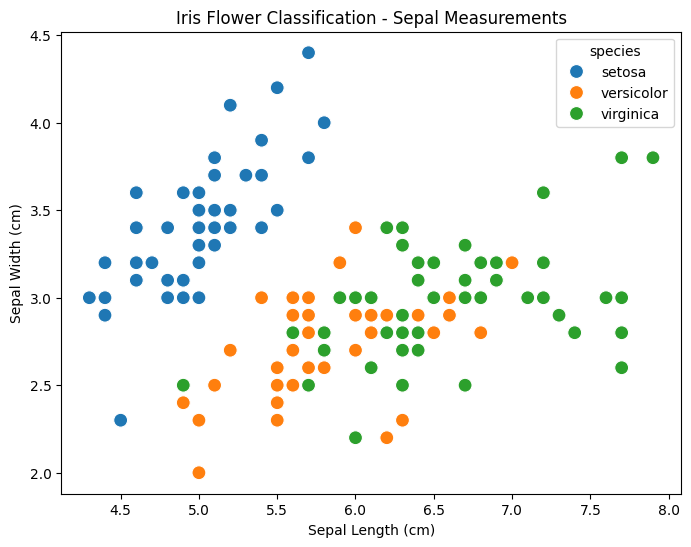

In [83]:
# Scatter plot of sepal length and sepal width

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    s=100
)

plt.title("Iris Flower Classification - Sepal Measurements")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()

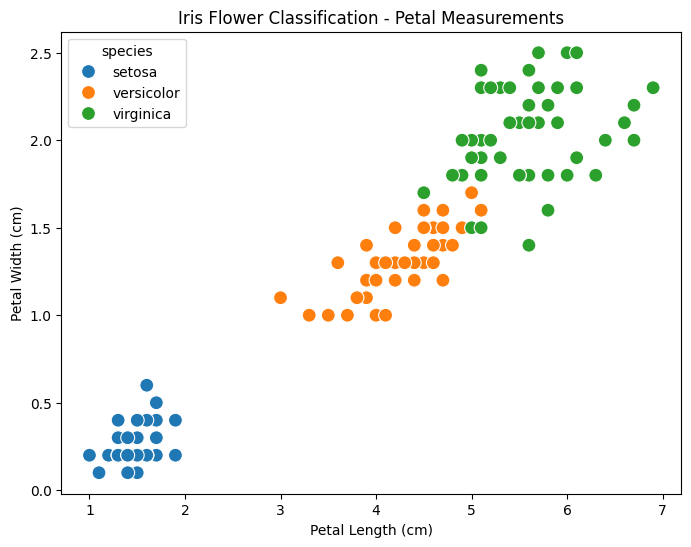

In [84]:
# Scatter plot of petal length and petal width

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=100
)

plt.title("Iris Flower Classification - Petal Measurements")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

In [85]:
# Split the dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [86]:
# Train a Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [87]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [88]:
# Calculate model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 96.67 %


In [89]:
# Display classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



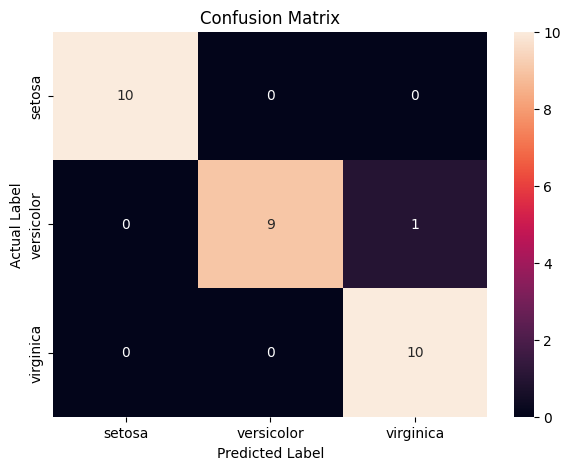

In [90]:
# Create a confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [91]:
# Predict the species of a new iris flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Flower Species:", predicted_species)

Predicted Flower Species: setosa


Conclusion

The Iris Flower Classification model successfully classified Iris flowers
into Setosa, Versicolor, and Virginica species using Logistic Regression.
The model achieved an accuracy of 96.67% on the test dataset.